In [1]:
import pandas as pd
from tensorflow.python.keras.backend import epsilon

from FRAME import FRAME
import numpy as np


/Users/lkiern/XAI_Framework/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
import ipywidgets as widgets
from IPython.display import display

# Create a simple integer slider
slider = widgets.IntSlider(value=50, min=0, max=100, description='Test Slider:')
display(slider)

IntSlider(value=50, description='Test Slider:')

In [3]:
import os
os.environ["GEMINI_API_KEY"] = "INSERT_YOUR_GEMINI_API_KEY_HERE"

In [4]:
categorical_values_dict = {
    "size":['small', 'medium', 'large', 'xlarge'],
    "breed_group":['terrier','herding','working','hound' , 'toy', 'sporting' , 'mixed'],
    "intake_type":['stray' ,'owner_surrender','transfer', 'born_in_care'],
    "previously_returned":[0,1],
    "medical_needs":['none' , 'minor' , 'chronic'],
    "neutered":[0,1],
    "house_trained": [0,1],
    "first_time_owner": [0,1],
    "household_has_kids": [0,1],
    "household_has_pets" : [0,1],
    "home_type": ['house_owned','house_rented','apartment'],
    "has_yard": [0,1],
    "adoption_counseling": [0,1],
    "met_resident_pets": [0,1]
}

In [5]:
class_value_map = {1: "adoption failed", 0: "adoption success"}

In [6]:
feature_bounds_xr = {"age_years":(0,20), "weight_kg":(0,90), "days_in_shelter": (0,365), "aggression_score":(0,10),"anxiety_separation":(0,10), "reactivity_to_dogs":(0,10), "energy_level":(0,10), "training_level":(0,10), "adopter_activity_level":(0,10), "hours_alone_per_day":(0,14), "visits_before_adoption":(0, 5), "expectation_score":(0,10), "energy_mismatch":(0,10),}

In [7]:
X_test = pd.read_csv('./XReason/dog_data_xtest_nonohe.csv')

In [8]:
X_test.columns

Index(['Unnamed: 0', 'age_years', 'size', 'weight_kg', 'breed_group',
       'intake_type', 'days_in_shelter', 'previously_returned',
       'medical_needs', 'neutered', 'aggression_score', 'anxiety_separation',
       'reactivity_to_dogs', 'energy_level', 'training_level', 'house_trained',
       'first_time_owner', 'household_has_kids', 'household_has_pets',
       'home_type', 'has_yard', 'hours_alone_per_day',
       'adopter_activity_level', 'visits_before_adoption', 'met_resident_pets',
       'adoption_counseling', 'expectation_score', 'energy_mismatch',
       'size_home_mismatch'],
      dtype='object')

#### Developer -feature imp

In [12]:
frame_xr = FRAME(
    model_path="./XReason/dogmodel2.mod.pkl",
    model_type="xgboost",
    categorical_values_dict=categorical_values_dict,
    feature_bounds= feature_bounds_xr,
    stakeholder_name = 'developer',
    time_limit=120,
    class_value_map=class_value_map
)

loading model from  ./XReason/dogmodel2.mod.pkl
loading datainfo from  ./XReason/dogmodel2.mod.pkl.splitdata.pkl
loading data from  ./XReason/dogmodel2.mod.pkl.splitdata.pkl


In [13]:
sample = X_test.iloc[7]

In [14]:
# changinf to diff prediction

sample2 = X_test.iloc[40]

In [15]:
sample3 = X_test.iloc[3]

In [16]:
sample4 = X_test.iloc[313]

In [17]:

sample.to_csv('./sample_1.csv')

In [18]:
sample2.to_csv('./sample_2.csv')

In [19]:
sample3.to_csv('./sample_3.csv')

In [20]:
sample4.to_csv('./sample_4.csv')

In [21]:
frame_xr.explain(sample,
            prediction_label="Prediction")

FFA Graph all: ./ffa_all.png
FFA Graph top5: ./ffa_top5.png


Accordion(children=(Tab(children=(HTML(value='\n                \n            <!DOCTYPE HTML>\n            <ht…

pred=0, proba(class=1)=0.033582
margin f(x)=-3.359621


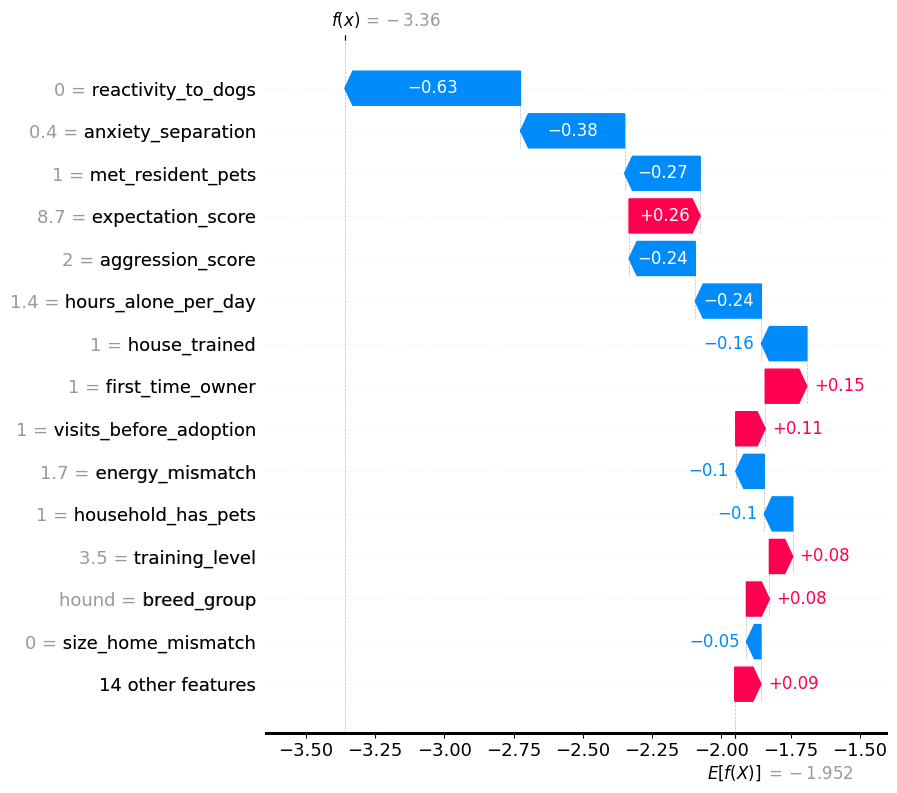

In [22]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# choose sample / sample2 / sample3 / sample4
sample_in = sample

xw = frame_xr.encoded_model          # XReason wrapper
model = xw.model                     # actual XGBClassifier
booster = model.get_booster()

# 1-row DataFrame
if isinstance(sample_in, pd.DataFrame):
    x_one = sample_in.copy()
elif isinstance(sample_in, pd.Series):
    x_one = sample_in.to_frame().T
else:
    x_one = pd.DataFrame([sample_in])

x_one = x_one.drop(columns=["Unnamed: 0"], errors="ignore")

# align to model feature order
model_cols = booster.feature_names or list(xw.feature_names)
x_one = x_one.reindex(columns=model_cols)

# categorical metadata from FRAME
cat_idx = set(xw.categorical_features)
cat_by_name = {xw.feature_names[i]: list(xw.categorical_names[i]) for i in cat_idx if i < len(xw.feature_names)}

# enforce dtypes: categorical for cat cols, numeric for others
for i, c in enumerate(model_cols):
    if c in cat_by_name:
        x_one[c] = pd.Categorical(x_one[c], categories=cat_by_name[c])
    else:
        x_one[c] = pd.to_numeric(x_one[c], errors="coerce")

# prediction sanity
pred = model.predict(x_one)[0]
proba1 = model.predict_proba(x_one)[0, 1]
print(f"pred={pred}, proba(class=1)={proba1:.6f}")

# SHAP from XGBoost contribs
dm = xgb.DMatrix(x_one, enable_categorical=True)
contrib = booster.predict(dm, pred_contribs=True)
phi = contrib[0, :-1]
base = contrib[0, -1]
print(f"margin f(x)={float(base + phi.sum()):.6f}")

exp = shap.Explanation(
    values=phi,
    base_values=base,
    data=x_one.iloc[0].values,
    feature_names=x_one.columns.tolist(),
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp, max_display=15)
plt.show()

In [23]:
frame_xr.explain(sample2,
            prediction_label="Prediction")

FFA Graph all: ./ffa_all.png
FFA Graph top5: ./ffa_top5.png


Accordion(children=(Tab(children=(HTML(value='\n                \n            <!DOCTYPE HTML>\n            <ht…

pred=0, proba(class=1)=0.489943
margin f(x)=-0.040232


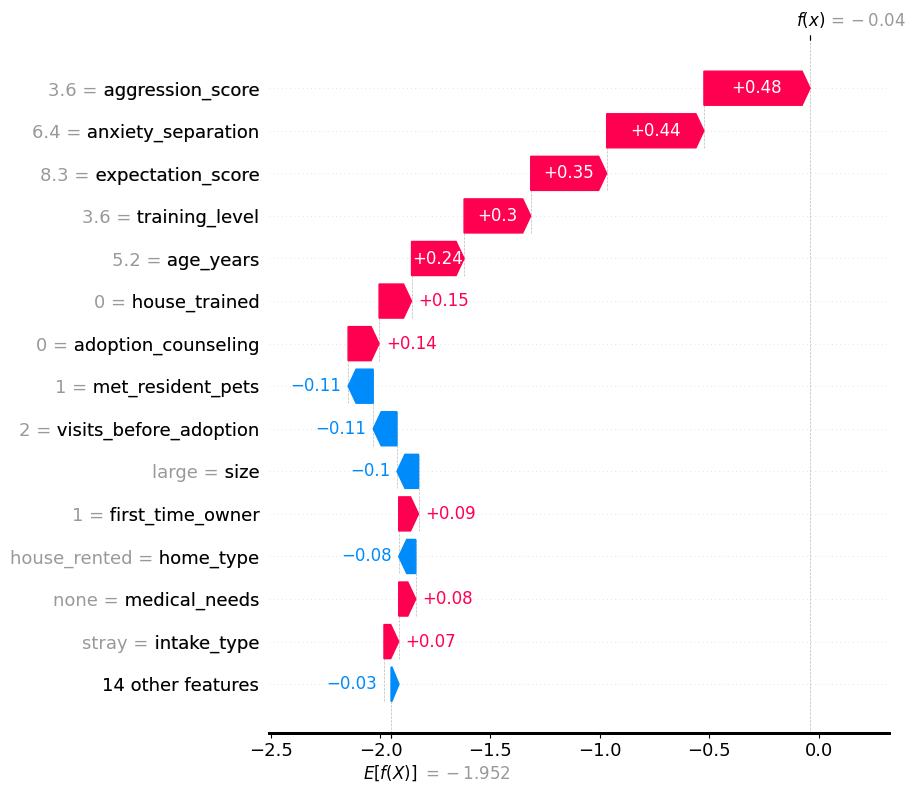

In [24]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# choose sample / sample2 / sample3 / sample4
sample_in = sample2

xw = frame_xr.encoded_model          # XReason wrapper
model = xw.model                     # actual XGBClassifier
booster = model.get_booster()

# 1-row DataFrame
if isinstance(sample_in, pd.DataFrame):
    x_one = sample_in.copy()
elif isinstance(sample_in, pd.Series):
    x_one = sample_in.to_frame().T
else:
    x_one = pd.DataFrame([sample_in])

x_one = x_one.drop(columns=["Unnamed: 0"], errors="ignore")

# align to model feature order
model_cols = booster.feature_names or list(xw.feature_names)
x_one = x_one.reindex(columns=model_cols)

# categorical metadata from FRAME
cat_idx = set(xw.categorical_features)
cat_by_name = {xw.feature_names[i]: list(xw.categorical_names[i]) for i in cat_idx if i < len(xw.feature_names)}

# enforce dtypes: categorical for cat cols, numeric for others
for i, c in enumerate(model_cols):
    if c in cat_by_name:
        x_one[c] = pd.Categorical(x_one[c], categories=cat_by_name[c])
    else:
        x_one[c] = pd.to_numeric(x_one[c], errors="coerce")

# prediction sanity
pred = model.predict(x_one)[0]
proba1 = model.predict_proba(x_one)[0, 1]
print(f"pred={pred}, proba(class=1)={proba1:.6f}")

# SHAP from XGBoost contribs
dm = xgb.DMatrix(x_one, enable_categorical=True)
contrib = booster.predict(dm, pred_contribs=True)
phi = contrib[0, :-1]
base = contrib[0, -1]
print(f"margin f(x)={float(base + phi.sum()):.6f}")

exp = shap.Explanation(
    values=phi,
    base_values=base,
    data=x_one.iloc[0].values,
    feature_names=x_one.columns.tolist(),
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp, max_display=15)
plt.show()

In [25]:
        frame_xr.explain(sample3,
            prediction_label="Prediction")

FFA Graph all: ./ffa_all.png
FFA Graph top5: ./ffa_top5.png


Accordion(children=(Tab(children=(HTML(value='\n                \n            <!DOCTYPE HTML>\n            <ht…

pred=0, proba(class=1)=0.153833
margin f(x)=-1.704850


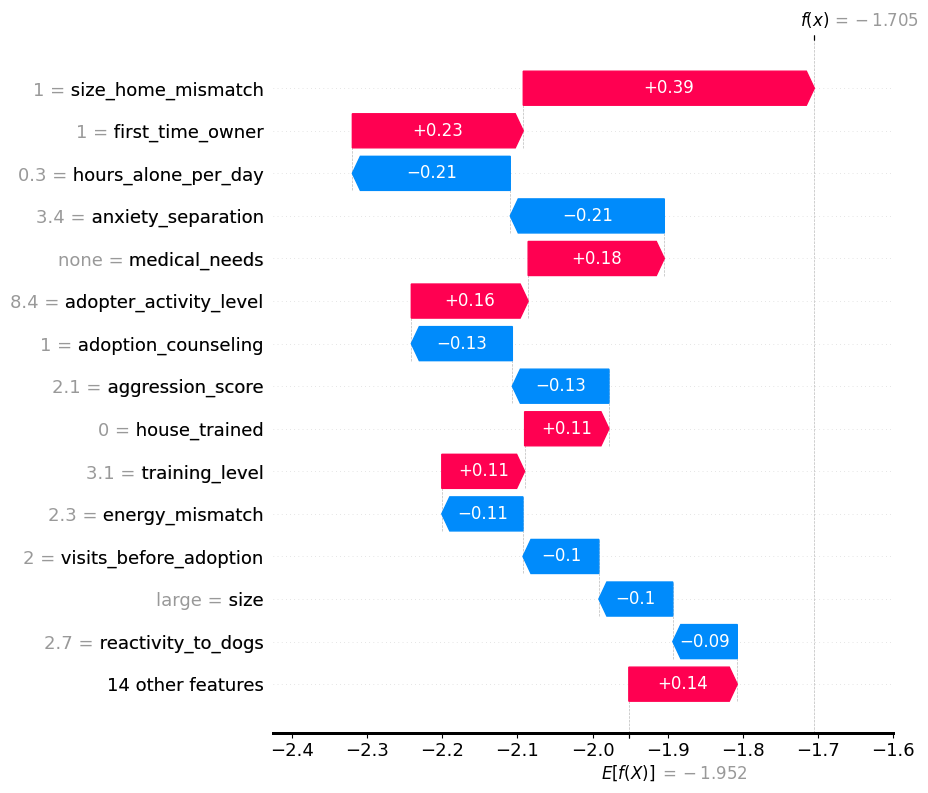

In [26]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# choose sample / sample2 / sample3 / sample4
sample_in = sample3

xw = frame_xr.encoded_model          # XReason wrapper
model = xw.model                     # actual XGBClassifier
booster = model.get_booster()

# 1-row DataFrame
if isinstance(sample_in, pd.DataFrame):
    x_one = sample_in.copy()
elif isinstance(sample_in, pd.Series):
    x_one = sample_in.to_frame().T
else:
    x_one = pd.DataFrame([sample_in])

x_one = x_one.drop(columns=["Unnamed: 0"], errors="ignore")

# align to model feature order
model_cols = booster.feature_names or list(xw.feature_names)
x_one = x_one.reindex(columns=model_cols)

# categorical metadata from FRAME
cat_idx = set(xw.categorical_features)
cat_by_name = {xw.feature_names[i]: list(xw.categorical_names[i]) for i in cat_idx if i < len(xw.feature_names)}

# enforce dtypes: categorical for cat cols, numeric for others
for i, c in enumerate(model_cols):
    if c in cat_by_name:
        x_one[c] = pd.Categorical(x_one[c], categories=cat_by_name[c])
    else:
        x_one[c] = pd.to_numeric(x_one[c], errors="coerce")

# prediction sanity
pred = model.predict(x_one)[0]
proba1 = model.predict_proba(x_one)[0, 1]
print(f"pred={pred}, proba(class=1)={proba1:.6f}")

# SHAP from XGBoost contribs
dm = xgb.DMatrix(x_one, enable_categorical=True)
contrib = booster.predict(dm, pred_contribs=True)
phi = contrib[0, :-1]
base = contrib[0, -1]
print(f"margin f(x)={float(base + phi.sum()):.6f}")

exp = shap.Explanation(
    values=phi,
    base_values=base,
    data=x_one.iloc[0].values,
    feature_names=x_one.columns.tolist(),
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp, max_display=15)
plt.show()

In [27]:
frame_xr.explain(sample4,
            prediction_label="Prediction")

FFA Graph all: ./ffa_all.png
FFA Graph top5: ./ffa_top5.png


Accordion(children=(Tab(children=(HTML(value='\n                \n            <!DOCTYPE HTML>\n            <ht…

pred=1, proba(class=1)=0.523788
margin f(x)=0.095224


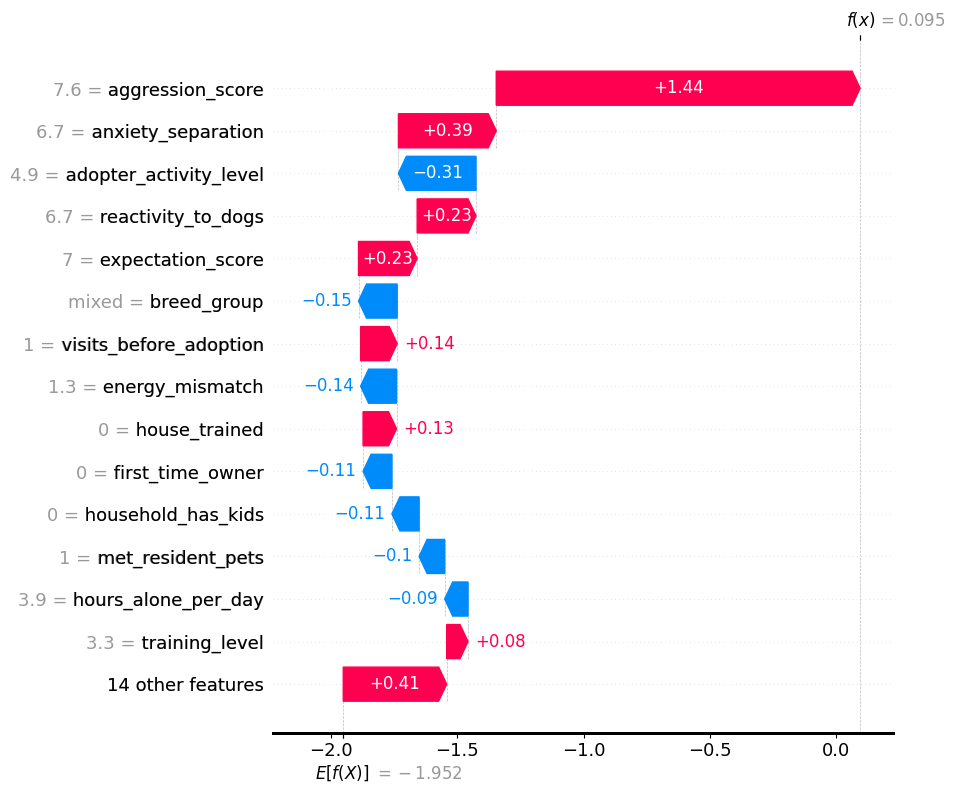

In [28]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# choose sample / sample2 / sample3 / sample4
sample_in = sample4

xw = frame_xr.encoded_model          # XReason wrapper
model = xw.model                     # actual XGBClassifier
booster = model.get_booster()

# 1-row DataFrame
if isinstance(sample_in, pd.DataFrame):
    x_one = sample_in.copy()
elif isinstance(sample_in, pd.Series):
    x_one = sample_in.to_frame().T
else:
    x_one = pd.DataFrame([sample_in])

x_one = x_one.drop(columns=["Unnamed: 0"], errors="ignore")

# align to model feature order
model_cols = booster.feature_names or list(xw.feature_names)
x_one = x_one.reindex(columns=model_cols)

# categorical metadata from FRAME
cat_idx = set(xw.categorical_features)
cat_by_name = {xw.feature_names[i]: list(xw.categorical_names[i]) for i in cat_idx if i < len(xw.feature_names)}

# enforce dtypes: categorical for cat cols, numeric for others
for i, c in enumerate(model_cols):
    if c in cat_by_name:
        x_one[c] = pd.Categorical(x_one[c], categories=cat_by_name[c])
    else:
        x_one[c] = pd.to_numeric(x_one[c], errors="coerce")

# prediction sanity
pred = model.predict(x_one)[0]
proba1 = model.predict_proba(x_one)[0, 1]
print(f"pred={pred}, proba(class=1)={proba1:.6f}")

# SHAP from XGBoost contribs
dm = xgb.DMatrix(x_one, enable_categorical=True)
contrib = booster.predict(dm, pred_contribs=True)
phi = contrib[0, :-1]
base = contrib[0, -1]
print(f"margin f(x)={float(base + phi.sum()):.6f}")

exp = shap.Explanation(
    values=phi,
    base_values=base,
    data=x_one.iloc[0].values,
    feature_names=x_one.columns.tolist(),
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp, max_display=15)
plt.show()

#### Model Subjects (plain text)

In [29]:
frame_xr = FRAME(
    model_path="./XReason/dogmodel2.mod.pkl",
    model_type="xgboost",
    categorical_values_dict=categorical_values_dict,
    feature_bounds= feature_bounds_xr,
    stakeholder_name = 'model_subject',
    time_limit=120,
    class_value_map=class_value_map
)

TypeError: __init__() got an unexpected keyword argument 'stakeholder_type'

In [ ]:
# changinf to diff prediction
sample = X_test.iloc[7]
sample3 = X_test.iloc[3]
sample4 = X_test.iloc[313]
sample2 = X_test.iloc[40]

In [ ]:
frame_xr.explain(sample,
            prediction_label="Rescue Failed")

In [ ]:
frame_xr.explain(sample2,
            prediction_label="Rescue Failed")

In [ ]:
frame_xr.explain(sample3,
            prediction_label="Rescue Failed")

In [ ]:
frame_xr.explain(sample4,
            prediction_label="Rescue Failed")

#### Decision Makers AXP CXP

In [ ]:
frame_xr = FRAME(
    model_path="./XReason/dogmodel2.mod.pkl",
    model_type="xgboost",
    categorical_values_dict=categorical_values_dict,
    stakeholder_name = 'decision_maker',
    time_limit=120,
    class_value_map=class_value_map
)

In [ ]:
frame_xr.explain(sample,
            prediction_label="Prediction")

In [ ]:
frame_xr.explain(sample2,
            prediction_label="Prediction")

In [ ]:
frame_xr.explain(sample3,
            prediction_label="Prediction")

In [ ]:
frame_xr.explain(sample4,
            prediction_label="Prediction")

In [ ]:
X_test_ohe = pd.read_csv('./VeriX/dog_data_ohe.csv')

In [ ]:
X_test_ohe = X_test_ohe.drop(columns=['Unnamed: 0'])

In [16]:
X_test_np = np.array(X_test_ohe, dtype=np.float32)

In [17]:
categorical_values_dict_ohe = {
    "size_small":[0,1],
    "size_medium":[0,1],
    "size_large":[0,1],
    "size_xlarge":[0,1],
    "breed_group_hound":[0,1],
    "breed_group_terrier":[0,1],
    "breed_group_herding":[0,1],
    "breed_group_working":[0,1],
    "breed_group_toy":[0,1],
    "breed_group_sporting":[0,1],
    "breed_group_mixed":[0,1],
    "intake_type_stray":[0,1],
    "intake_type_owner_surrender":[0,1],
    "intake_type_transfer":[0,1],
    "intake_type_born_in_care":[0,1],
    "previously_returned":[0,1],
    "medical_needs_none":[0,1],
    "medical_needs_minor":[0,1],
    "medical_needs_chronic":[0,1],
    "neutered":[0,1],
    "house_trained": [0,1],
    "first_time_owner": [0,1],
    "household_has_kids": [0,1],
    "household_has_pets" : [0,1],
    "home_type_house_owned":[0,1],
    "home_type_house_rented":[0,1],
    "home_type_apartment":[0,1],
    "has_yard": [0,1],
    "adoption_counseling": [0,1],
    "met_resident_pets": [0,1]
}

In [18]:
one_hot_groups=[["size_small", "size_medium", "size_large","size_xlarge"],
                ["breed_group_hound","breed_group_terrier","breed_group_herding","breed_group_working","breed_group_toy","breed_group_sporting","breed_group_mixed"],
                ["intake_type_stray","intake_type_owner_surrender","intake_type_transfer","intake_type_born_in_care"],
                ["medical_needs_none","medical_needs_minor","medical_needs_chronic"],
                ["home_type_house_owned","home_type_house_rented","home_type_apartment"],]

In [19]:
feature_names = X_test_ohe.columns.tolist()

In [20]:
frame_verix = FRAME(
    model_path="./VeriX/models/shelter_returns.onnx",
    model_type='neural_network',
    categorical_values_dict=categorical_values_dict_ohe,
    one_hot_groups=one_hot_groups,
    feature_names= feature_names,
    stakeholder_name = 'developer',
    time_limit=120,
)

In [21]:
frame_verix.explain(X_test_np[3],
            prediction_label="Rescue Failed",     epsilon = 5,)

Relevant features (sat): []
Irrelevant features (unsat): [43]
Timeout features: []
n:44
exiting enumeration
sat_set: []
expl_strings: {'abd': ['IF age_years = 2.0 THEN label = 0', 'IF aggression_score = 2.0999999046325684 AND visits_before_adoption = 2.0 AND size_home_mismatch = 1.0 THEN label = 0', 'IF aggression_score = 2.0999999046325684 AND energy_mismatch = 2.299999952316284 AND size_home_mismatch = 1.0 THEN label = 0', 'IF visits_before_adoption = 2.0 AND expectation_score = 6.199999809265137 AND energy_mismatch = 2.299999952316284 AND size_home_mismatch = 1.0 THEN label = 0', 'IF aggression_score = 2.0999999046325684 AND visits_before_adoption = 2.0 AND adoption_counseling = 1.0 AND energy_mismatch = 2.299999952316284 THEN label = 0'], 'con': ['IF age_years = -3.0 AND aggression_score = 6.81509 AND training_level = -1.9 AND visits_before_adoption = -3.0 AND energy_mismatch = -2.7 THEN label = 1', 'IF age_years = -3.0 AND aggression_score = 6.24961 AND training_level = -1.9 AND e

Accordion(children=(Tab(children=(HTML(value='\n                \n            <!DOCTYPE HTML>\n            <ht…

In [22]:
frame_verix = FRAME(
    model_path="./VeriX/models/shelter_returns.onnx",
    model_type='neural_network',
    categorical_values_dict=categorical_values_dict_ohe,
    one_hot_groups=one_hot_groups,
    feature_names= feature_names,
    stakeholder_name = 'decision_maker',
    time_limit=120,
)

In [23]:
frame_verix.explain(X_test_np[3],
            prediction_label="Rescue Failed",     epsilon = 5,)

Relevant features (sat): []
Irrelevant features (unsat): [43]
Timeout features: []
n:44
exiting enumeration
sat_set: []
expl_strings: {'abd': ['IF training_level = 3.0999999046325684 AND visits_before_adoption = 2.0 AND energy_mismatch = 2.299999952316284 AND size_home_mismatch = 1.0 THEN label = 0', 'IF previously_returned = 0.0 AND visits_before_adoption = 2.0 AND adoption_counseling = 1.0 AND energy_mismatch = 2.299999952316284 AND size_home_mismatch = 1.0 THEN label = 0'], 'con': ['IF aggression_score = 7.1 AND anxiety_separation = -1.6 AND visits_before_adoption = -3.0 AND energy_mismatch = 4.43459 THEN label = 1', 'IF training_level = -1.9 AND visits_before_adoption = -3.0 AND expectation_score = 1.2 AND energy_mismatch = -0.00869 AND size_home_mismatch = 6.0 THEN label = 1']}
DEBUG: in_jupyter=True, datatype=tabular
DEBUG: Calling show_in_jupyter


Accordion(children=(Tab(children=(HTML(value='\n                \n            <!DOCTYPE HTML>\n            <ht…

In [24]:
frame_verix = FRAME(
    model_path="./VeriX/models/shelter_returns.onnx",
    model_type='neural_network',
    categorical_values_dict=categorical_values_dict_ohe,
    one_hot_groups=one_hot_groups,
    feature_names= feature_names,
    stakeholder_type = 'model_subject',
    time_limit=120,
)

In [25]:
frame_verix.explain(X_test_np[3],
            prediction_label="Rescue Failed",     epsilon = 5,)

Relevant features (sat): []
Irrelevant features (unsat): [43]
Timeout features: []
n:44
exiting enumeration


sat_set: []
expl_strings: {'abd': ['IF training_level = 3.0999999046325684 AND visits_before_adoption = 2.0 AND energy_mismatch = 2.299999952316284 AND size_home_mismatch = 1.0 THEN label = 0'], 'con': ['IF aggression_score = 7.1 AND anxiety_separation = -1.6 AND visits_before_adoption = -3.0 AND energy_mismatch = 4.43459 THEN label = 1', 'IF training_level = -1.9 AND visits_before_adoption = -3.0 AND expectation_score = 1.2 AND energy_mismatch = -0.00869 AND size_home_mismatch = 6.0 THEN label = 1']}
DEBUG: in_jupyter=True, datatype=tabular
DEBUG: Calling show_in_jupyter


Accordion(children=(Tab(children=(HTML(value='\n                        <div class="box">\n                   …

In [26]:
X_train_ohe = pd.read_csv('./foxplainer/X_train_dog.csv')
X_train_ohe = X_train_ohe.drop(columns=['Unnamed: 0'])

In [27]:
feature_bounds = {
    i: (float(X_train_ohe.iloc[:, i].min()), float(X_train_ohe.iloc[:, i].max()))
    for i in range(X_train_ohe.shape[1])
}

In [28]:
feature_names = X_test_ohe.columns

In [29]:
frame_lr = FRAME(
    model_path="./foxplainer/models/LR_dog_model.pkl",
    model_type='logistic_regression',
    categorical_values_dict=categorical_values_dict_ohe,
    one_hot_groups=one_hot_groups,
    feature_names= feature_names,
    feature_bounds = feature_bounds,
    stakeholder_name = 'developer',
    time_limit=120,
)

Prediction: 0
Probabilities: [0.94487486 0.05512514]


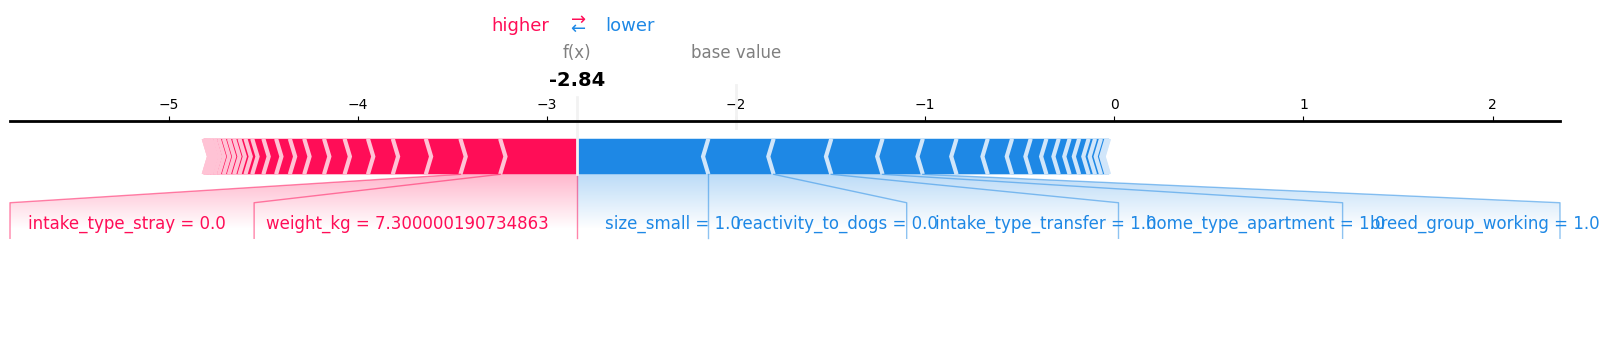

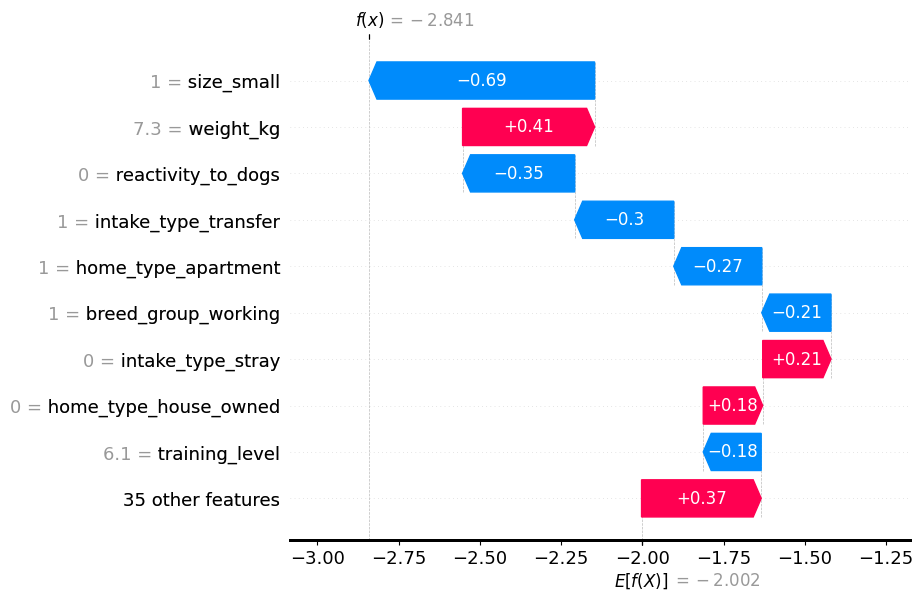

In [30]:
# If needed once:
# !.venv/bin/pip install shap

import pickle
import numpy as np
import pandas as pd
import shap

# Load the sklearn logistic regression model used by FRAME/FoX
with open(frame_lr.encoded_model.options.classifier, "rb") as f:
    lr_model = pickle.load(f)

# Feature names
feature_names = list(frame_lr.encoded_model.dataset.feature_names)

# Build DataFrame inputs for SHAP
X_df = pd.DataFrame(X_test_np, columns=feature_names)
x_one = X_df.iloc[[9]]

# Background set for LinearExplainer (keep it small/fast)
bg = X_df.sample(n=min(100, len(X_df)), random_state=0)

explainer = shap.LinearExplainer(lr_model, bg)
sv = explainer(x_one)

print("Prediction:", lr_model.predict(x_one)[0])
print("Probabilities:", lr_model.predict_proba(x_one)[0])

# Force plot + waterfall for the single instance
shap.initjs()
shap.plots.force(sv[0], matplotlib=True)
shap.plots.waterfall(sv[0])

In [31]:
frame_lr.explain(X_test_np[9],
            prediction_label="Rescue Failed")


Explaining the logistic regression model...

Entering Feature Attribution
2139
min lits: 10, max lits: 22, avg: 14.74


Accordion(children=(Tab(children=(HTML(value='\n                \n            <!DOCTYPE HTML>\n            <ht…

In [32]:
frame_lr = FRAME(
    model_path="./foxplainer/models/LR_dog_model.pkl",
    model_type='logistic_regression',
    categorical_values_dict=categorical_values_dict_ohe,
    one_hot_groups=one_hot_groups,
    feature_names= feature_names,
    feature_bounds = feature_bounds,
    stakeholder_type = 'decision_maker',
    time_limit=120,
)

In [33]:
frame_lr.explain(X_test_np[9],
            prediction_label="Rescue Failed")


Explaining the logistic regression model...



Accordion(children=(Tab(children=(HTML(value='\n                \n            <!DOCTYPE HTML>\n            <ht…

In [34]:
frame_lr = FRAME(
    model_path="./foxplainer/models/LR_dog_model.pkl",
    model_type='logistic_regression',
    categorical_values_dict=categorical_values_dict_ohe,
    one_hot_groups=one_hot_groups,
    feature_names= feature_names,
    feature_bounds = feature_bounds,
    stakeholder_type = 'model_subject',
    time_limit=120,
)

In [35]:
frame_lr.explain(X_test_np[9],
            prediction_label="Rescue Failed")


Explaining the logistic regression model...



Accordion(children=(Tab(children=(HTML(value='\n                            <div style="padding:12px; border:1…

In [36]:
frame_rf = FRAME(
    model_path="./foxplainer/models/dog_RF_30estimators_model.pkl",
    model_type='random_forest',
    categorical_values_dict=categorical_values_dict_ohe,
    feature_names= feature_names,
    feature_bounds = feature_bounds,
    stakeholder_name = 'developer',
    time_limit=120,
)

In [37]:
frame_rf.explain(X_test_np[9],
            prediction_label="Rescue Failed")


Explaining the random forest model...

time taken for unit-size MCSes: 0.02 seconds
exiting enumeration
Entering Feature Attribution
1
min lits: 26, max lits: 26, avg: 26.00


Accordion(children=(Tab(children=(HTML(value='\n                \n            <!DOCTYPE HTML>\n            <ht…

In [38]:
frame_rf = FRAME(
    model_path="./foxplainer/models/dog_RF_30estimators_model.pkl",
    model_type='random_forest',
    categorical_values_dict=categorical_values_dict_ohe,
    feature_names= feature_names,
    feature_bounds = feature_bounds,
    stakeholder_type = 'model_subject',
    time_limit=120,
)

In [39]:
frame_rf.explain(X_test_np[9],
            prediction_label="Rescue Failed")


Explaining the random forest model...

time taken for unit-size MCSes: 0.02 seconds
exiting enumeration


Accordion(children=(Tab(children=(HTML(value='\n                            <div style="padding:12px; border:1…

In [40]:
frame_rf = FRAME(
    model_path="./foxplainer/models/dog_RF_30estimators_model.pkl",
    model_type='random_forest',
    categorical_values_dict=categorical_values_dict_ohe,
    feature_names= feature_names,
    feature_bounds = feature_bounds,
    stakeholder_type = 'decision_maker',
    time_limit=120,
)

In [41]:
frame_rf.explain(X_test_np[9],
            prediction_label="Rescue Failed")


Explaining the random forest model...

time taken for unit-size MCSes: 0.02 seconds
exiting enumeration


Accordion(children=(Tab(children=(HTML(value='\n                \n            <!DOCTYPE HTML>\n            <ht…